In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import minimize
from statsmodels.graphics.tsaplots import plot_acf
import math

import sys
sys.path.append('..')
from src.price_model import *
from src.optimization import *
from src.simulation import *

DATA_DIR = Path("../data")
ciso = pd.read_csv(DATA_DIR / "prices_CISO.csv")
nyiso = pd.read_csv(DATA_DIR / "prices_NYIS.csv")

# Parse datetime and extract components
ciso["hour"] = pd.to_datetime(ciso["hour"])
ciso["hour_of_day"] = ciso["hour"].dt.hour
ciso["dow"] = ciso["hour"].dt.dayofweek
ciso["month"] = ciso["hour"].dt.month

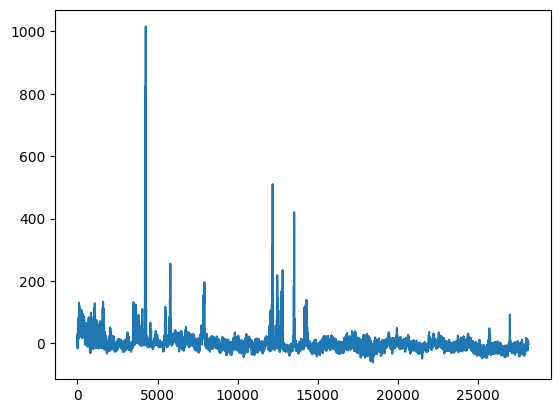

In [10]:
dummies = pd.get_dummies(ciso[["hour_of_day","dow","month"]], columns = ["hour_of_day","dow","month"], drop_first = True, dtype=float)
dummies = sm.add_constant(dummies)

seasonal_model = sm.OLS(ciso["price_usd_mwh"], dummies).fit()
residuals = seasonal_model.resid
residuals.plot()
plt.show()

<Axes: xlabel='hour_of_day'>

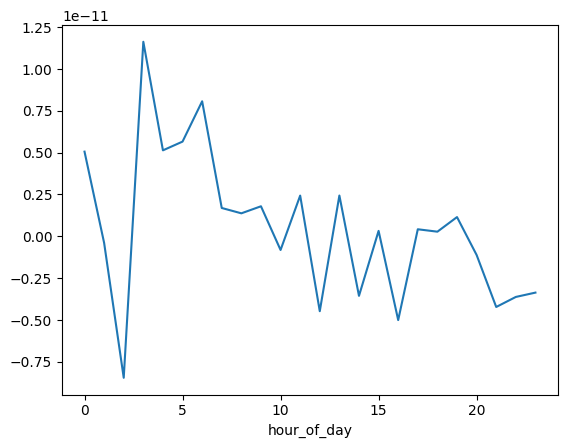

In [6]:
ciso["resid"] = residuals
ciso.groupby("hour_of_day")["resid"].mean().plot()

<Axes: xlabel='month'>

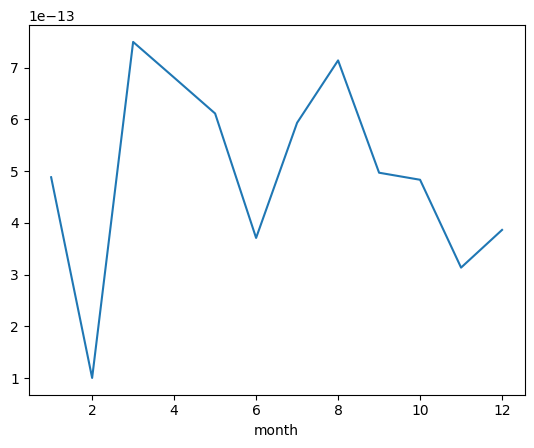

In [7]:
ciso.groupby("month")["resid"].mean().plot()

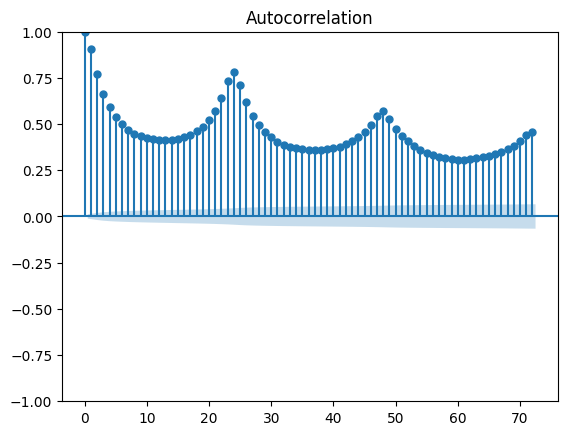

In [8]:
plot_acf(residuals, lags = 72)
plt.show()

In [11]:
seasonal_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_usd_mwh   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     279.2
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:44:00   Log-Likelihood:            -1.2930e+05
No. Observations:               28144   AIC:                         2.587e+05
Df Residuals:                   28103   BIC:                         2.590e+05
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             58.2646      0.922     63.211      0.000      56.458      60.071
hour_of_day_1     13.0242      0.990     13.162      0.000      11.085      14.964
hour_of_day_2     19.3727      0.990     19.578      0.000      17.433      21.312
hour_of_day_3     12.8640      0.990     13.000      0.000      10.924      14.803
hour_of_day_4      7.3140      0.990      7.391      0.000       5.374       9.254
hour_of_day_5      3.2560      0.990      3.290      0.001       1.316       5.196
hour_of_day_6      0.0435      0.990      0.044      0.965      -1.896       1.983
hour_of_day_7     -2.1464      0.990     -2.169      0.030      -4.086      -0.207
hour_of_day_8     -3.8255      0.989     -3.867      0.000      -5.765      -1.886
hour_of_day_9     -5.0581      0.989     -5.113      0.000      -6.997      -3.119
hour_of_day_10    -5.7099      0.989     -5.771      0.000      -7.649      -3.771
hour_of_day_11    -5.1126      0.989     -5.168      0.000      -7.052      -3.173
hour_of_day_12    -2.1212      0.989     -2.144      0.032      -4.060      -0.182
hour_of_day_13     1.5680      0.989      1.585      0.113      -0.371       3.507
hour_of_day_14    -1.7810      0.989     -1.800      0.072      -3.720       0.158
hour_of_day_15    -8.3764      0.989     -8.467      0.000     -10.316      -6.437
hour_of_day_16   -12.8894      0.989    -13.028      0.000     -14.829     -10.950
hour_of_day_17   -16.2762      0.989    -16.452      0.000     -18.215     -14.337
hour_of_day_18   -18.4889      0.989    -18.688      0.000     -20.428     -16.550
hour_of_day_19   -20.0930      0.989    -20.310      0.000     -22.032     -18.154
hour_of_day_20   -20.4322      0.989    -20.653      0.000     -22.371     -18.493
hour_of_day_21   -19.5514      0.989    -19.762      0.000     -21.491     -17.612
hour_of_day_22   -16.6216      0.989    -16.801      0.000     -18.561     -14.682
hour_of_day_23   -11.4253      0.989    -11.549      0.000     -13.364      -9.486
dow_1              2.7620      0.534      5.174      0.000       1.716       3.808
dow_2              2.7770      0.534      5.202      0.000       1.731       3.823
dow_3              2.4894      0.534      4.662      0.000       1.443       3.536
dow_4              1.5363      0.535      2.873      0.004       0.488       2.584
dow_5             -2.7340      0.535     -5.113      0.000      -3.782      -1.686
dow_6             -5.0740      0.535     -9.491      0.000      -6.122      -4.026
month_2          -10.6746      0.716    -14.912      0.000     -12.078      -9.272
month_3          -13.3960      0.671    -19.969      0.000     -14.711     -12.081
month_4          -24.2456      0.676    -35.889      0.000     -25.570     -22.921
month_5          -32.9346      0.704    -46.756      0.000     -34.315     -31.554
month_6     

In [13]:
fourier_model, cols = fit_seasonal_fourier(ciso)
fourier_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_usd_mwh   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     497.0
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:51:31   Log-Likelihood:            -1.2939e+05
No. Observations:               28144   AIC:                         2.588e+05
Df Residuals:                   28121   BIC:                         2.590e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          41.7966      0.379    110.277      0.000      41.054      42.539
hour_sin_1     11.0437      0.202     54.537      0.000      10.647      11.441
hour_cos_1      1.9124      0.202      9.444      0.000       1.516       2.309
month_sin_1    -6.2158      0.200    -31.005      0.000      -6.609      -5.823
month_cos_1     9.9393      0.207     48.097      0.000       9.534      10.344
hour_sin_2      8.3361      0.202     41.168      0.000       7.939       8.733
hour_cos_2      4.8100      0.203     23.753      0.000       4.413       5.207
month_sin_2     5.7064      0.204     27.977      0.000       5.307       6.106
month_cos_2    -1.1302      0.203     -5.566      0.000      -1.528      -0.732
hour_sin_3      2.0719      0.202     10.232      0.000       1.675       2.469
hour_cos_3     -0.3109      0.202     -1.535      0.125      -0.708       0.086
month_sin_3    -3.9710      0.203    -19.564      0.000      -4.369      -3.573
month_cos_3     0.3913      0.204      1.920      0.055      -0.008       0.791
hour_sin_4      3.1142      0.202     15.379      0.000       2.717       3.511
hour_cos_4     -0.1465      0.202     -0.723      0.469      -0.543       0.250
month_sin_4     2.3623      0.204     11.594      0.000       1.963       2.762
month_cos_4    -2.5129      0.203    -12.401      0.000      -2.910      -2.116
dow_1           2.7520      0.535      5.141      0.000       1.703       3.801
dow_2           2.8250      0.535      5.277      0.000       1.776       3.874
dow_3           2.5551      0.535      4.773      0.000       1.506       3.604
dow_4           1.6263      0.536      3.034      0.002       0.575       2.677
dow_5          -2.6772      0.536     -4.994      0.000      -3.728      -1.626
dow_6          -5.0441      0.536     -9.409      0.000      -6.095      -3.993
==============================================================================
Omnibus:                    46335.810   Durbin-Watson:                   0.187
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        111967952.843
Skew:                          10.554   Prob(JB):                         0.00
Kurtosis:                     311.279   Cond. No.                         7.92
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

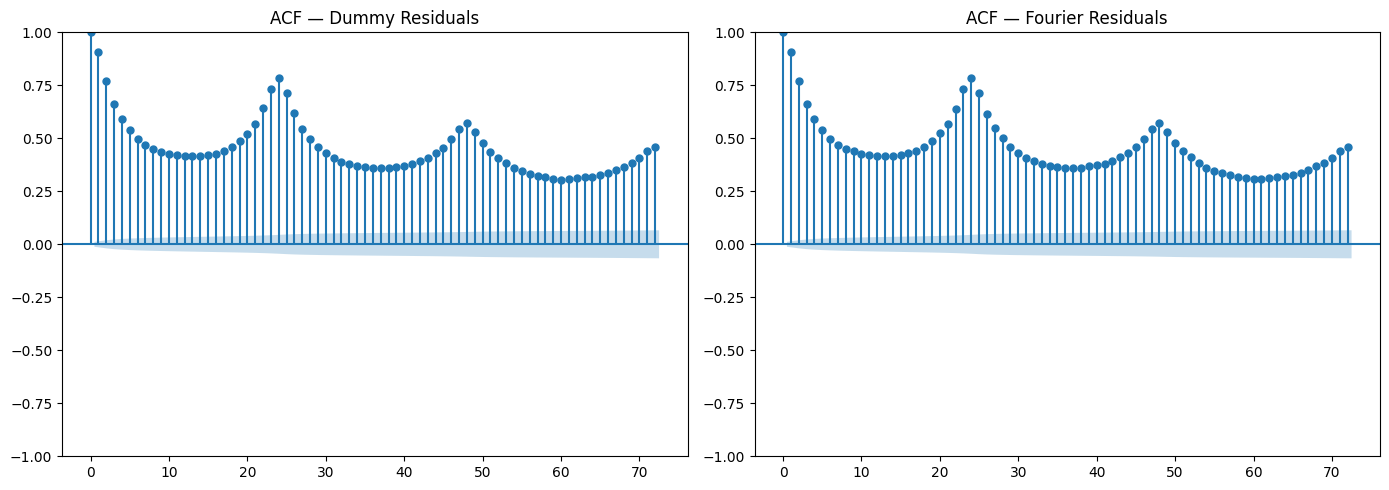

In [17]:
fourier_residuals = fourier_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(residuals, lags=72, ax=axes[0])
axes[0].set_title("ACF — Dummy Residuals")

plot_acf(fourier_residuals, lags=72, ax=axes[1])
axes[1].set_title("ACF — Fourier Residuals")

plt.tight_layout()
plt.show()

We can see here that both models perform equally well in-sample (similar ACF plots, and R-squared of 0.284 versus 0.280). However, we elect to proceed using the Fourier model due to out-of-sample resilience, optimizing for higher bias and lower variance.

In [29]:
theta, mu, sigma = estimate_ou_params(fourier_residuals)
print(f"(θ, μ, σ) = {theta, mu, sigma}")

(θ, μ, σ) = (0.09817555322771178, -0.0003024727112085934, 10.639622277649627)


In [34]:
X_grid = np.linspace(-100,200,80)
soc_grid = np.linspace(0, 100, 41)
params = {"u_max":25, "eta":0.85, "S_max":100, "S_0": 0, "dt":1}
start_idx = 0
T = 24 * 14  # two weeks (eval + buffer)
f = fourier_model.fittedvalues.values[start_idx:start_idx + T]
params["q"] = ciso["price_usd_mwh"][start_idx:start_idx + T].mean()

trans = build_transition_matrix(ciso, theta, mu, sigma, X_grid)
policy = get_optimal_policy(trans, f, X_grid, soc_grid, params)

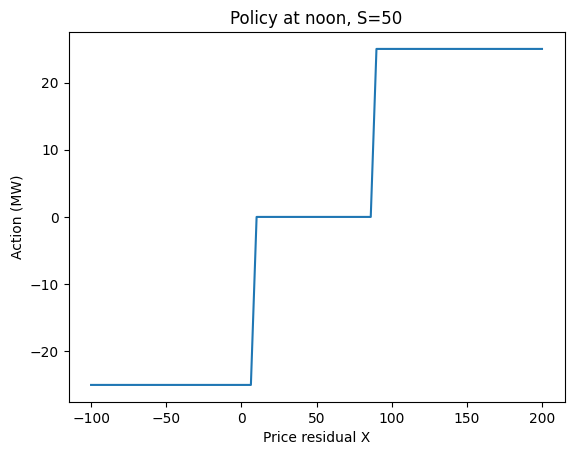

In [35]:
s_idx = len(soc_grid) // 2  # S = 50
plt.plot(X_grid, policy[12, :, s_idx])
plt.xlabel("Price residual X")
plt.ylabel("Action (MW)")
plt.title("Policy at noon, S=50")
plt.show()

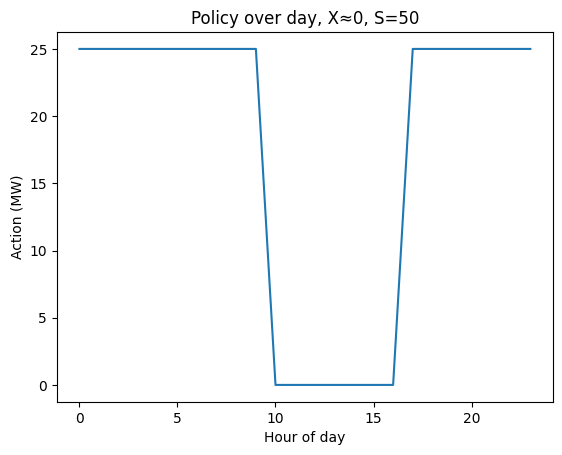

In [36]:
x_idx = len(X_grid) // 2  # X ≈ 0
plt.plot(range(24), policy[:24, x_idx, s_idx])
plt.xlabel("Hour of day")
plt.ylabel("Action (MW)")
plt.title("Policy over day, X≈0, S=50")
plt.show()

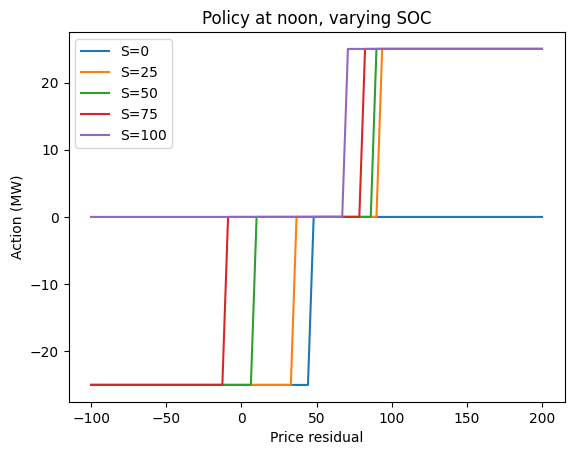

In [37]:
for j in [0, len(soc_grid)//4, len(soc_grid)//2, 3*len(soc_grid)//4, len(soc_grid)-1]:
    plt.plot(X_grid, policy[12, :, j], label=f"S={soc_grid[j]:.0f}")
plt.legend()
plt.xlabel("Price residual")
plt.ylabel("Action (MW)")
plt.title("Policy at noon, varying SOC")
plt.show()

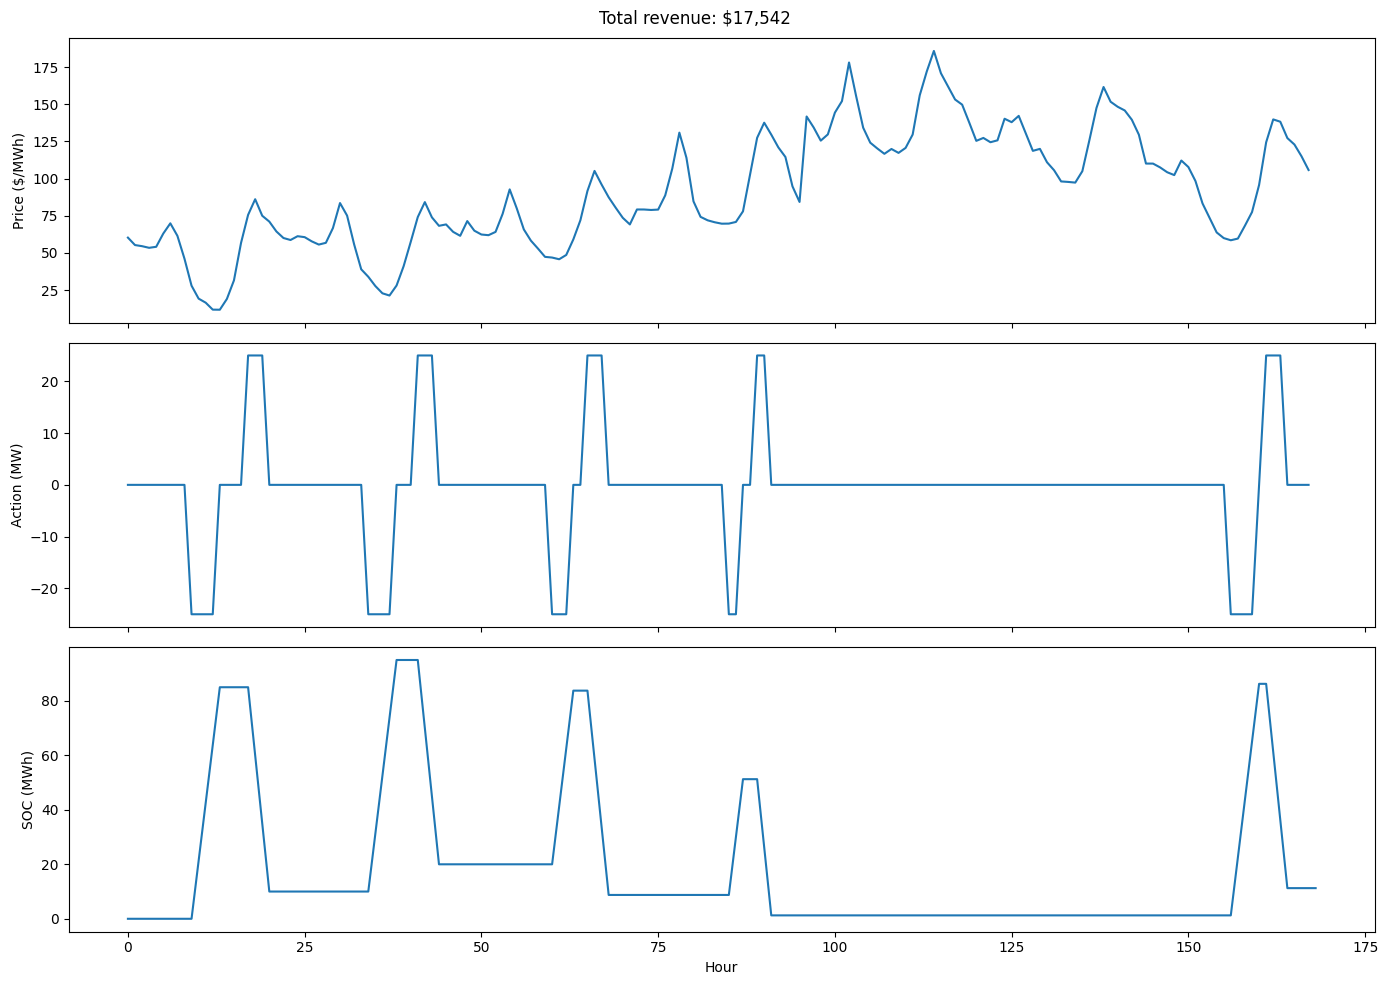

In [38]:
T_eval = 24 * 7
X_actual = fourier_model.resid.values[start_idx:start_idx + T_eval]
f_eval = f[:T_eval]

rev, traj = simulate(policy, f_eval, X_actual, X_grid, soc_grid, params, T_eval=T_eval)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(f_eval + X_actual)
axes[0].set_ylabel("Price ($/MWh)")
axes[1].plot([policy[t, np.argmin(np.abs(X_grid - X_actual[t])),
              np.argmin(np.abs(soc_grid - traj[t]))] for t in range(T_eval)])
axes[1].set_ylabel("Action (MW)")
axes[2].plot(traj)
axes[2].set_ylabel("SOC (MWh)")
axes[2].set_xlabel("Hour")
plt.suptitle(f"Total revenue: ${rev:,.0f}")
plt.tight_layout()
plt.show()